# Tutorial 8: Single-Cell Foundation Model Embeddings

This notebook demonstrates how to extract **cell embeddings** from state-of-the-art single-cell RNA-seq foundation models using `embpy`, and -- for the encoder-decoder families -- how to **decode** latent codes back to gene expression or **generate** expression for unseen cells in-context.

### Model families

`embpy` groups 25+ single-cell models into three capability classes, all behind a single API (`get_singlecell_wrapper`, `BioEmbedder.embed_cells`, `decode_cells`, `generate_cells`):

#### (a) Encoder-only foundation models (via [Helical](https://github.com/helicalAI/helical))

Embed cells -> fixed-length latent. No decoder.

| Family | Variants | Reference |
|---|---|---|
| **scGPT** | 33M-cell transformer | [Cui et al. 2024](https://doi.org/10.1038/s41592-024-02201-0) |
| **Geneformer** | v1 (6L/12L), v2 (12L/18L/20L), cancer-tuned | [Theodoris et al. 2023](https://doi.org/10.1038/s41586-023-06139-9) |
| **UCE** | Cross-species (36M cells) | [Rosen et al. 2023](https://doi.org/10.1101/2023.11.28.568918) |
| **TranscriptFormer** | Metazoa / Exemplar / Sapiens (CZI) | [Fang et al. 2025](https://doi.org/10.1101/2025.04.25.650731) |
| **Tahoe-x1** | 70M / 1B / 3B | [Arc Institute](https://arcinstitute.org/) |
| **Cell2Sentence-Scale** | 2B (Pythia) / 27B (Gemma-2) | [Levine et al. 2024](https://doi.org/10.1101/2024.09.14.613180) |

#### (b) Encoder-decoder models (latent <-> gene expression)

Fit an encoder **and** a decoder -- the decoder is the hook that perturbation flow-matching / CellFlow-style models plug into.

| Model | Decoder | Reference |
|---|---|---|
| **PCA** | linear (analytic inverse, scikit-learn) | baseline |
| **scVI / scANVI / totalVI** | probabilistic (negative-binomial `px_rate`) | [Lopez et al. 2018](https://doi.org/10.1038/s41592-018-0229-2) |
| **STATE** | learned, gene-parametric log-prob decoder | [Arc Institute / state](https://github.com/ArcInstitute/state) |

#### (c) In-context generators

No fixed latent to decode; instead, **generate** expression for a *test* set of cells conditioned on a *context* set.

| Model | Task | Reference |
|---|---|---|
| **Stack** | in-context expression prediction | [Arc Institute / stack](https://github.com/ArcInstitute/stack) |

Every model's capability flags (`supports_decode`, `supports_generation`) are programmatically discoverable via `singlecell_info(key)` and the table below is rendered live in Section 1.

### What you'll learn

1. List and inspect all models by capability (encoder / decoder / generator)
2. Load a model and extract cell embeddings from an AnnData
3. Compare embedding spaces across models (UMAP + cross-model RSA-style agreement)
4. Scale to real datasets: auto gene-vocabulary conversion + wrapper caching + explicit GPU cleanup
5. **Decode** latents back to gene expression (PCA, scVI, STATE) -- the hook for perturbation flow-matching
6. **Generate** expression for unseen cells in-context (Stack)

### Requirements - Pixi environments

Because the foundation models in this notebook come from two different ecosystems with **incompatible pinned dependencies**, `embpy` ships two dedicated Pixi environments. **You must launch JupyterLab against the right one before opening this notebook:**

| Section | Models | Pixi env | Launcher |
|---|---|---|---|
| Sections 1-12 | scGPT, Geneformer, UCE, TranscriptFormer, Tahoe-x1, Cell2Sentence, PCA, scVI | `helical-gpu` | `sbatch submission_scripts/jupyter_pixi_helical.sbatch` |
| Section 13c | **STATE, Stack** (Arc Institute) | `arc-gpu` | `sbatch submission_scripts/jupyter_pixi_arc.sbatch` |

**One-time install** (run on the login node, from the repo root):

```bash
# For sections 1-12:
CONDA_OVERRIDE_CUDA=12.0 pixi install -e helical-gpu

# For section 13c:
CONDA_OVERRIDE_CUDA=12.0 pixi install -e arc-gpu
```

**Launch** (from the repo root):

```bash
sbatch submission_scripts/jupyter_pixi_helical.sbatch    # for 1-12
# OR
sbatch submission_scripts/jupyter_pixi_arc.sbatch        # for 13c
```

The sbatch output log (at `submission_scripts/logs/jupyter_pixi_*_<JOBID>.out`) prints the URL + token to paste into the Cursor/VSCode "Existing Jupyter Server..." kernel picker.

If you prefer to install `embpy` outside of Pixi:

```bash
pip install embpy[helical]           # sections 1-12
pip install arc-state arc-stack       # section 13c (needs torch>=2.7, scipy>=1.15)
```

## Preferred workflow: cell embeddings stay aligned to AnnData

Single-cell foundation models are experiment-level encoders: the expression/count matrix remains in `.X`, while generated cell embeddings belong in `.obsm`. The preferred post-embedding workflow is:

1. Generate cell embeddings with the single-cell APIs shown below.
2. Register the resulting `.obsm` matrix with `adata.embpy.register_embedding(...)` so dimensions, model provenance, entity type, and ID scheme are explicit.
3. Use `adata.embpy` for aggregation, neighbors, phenotype correlation, cross-model comparison, plotting, prompt summaries, and perturbation/action datasets.

`BioEmbedder.embed(...)` remains the standardized entry point for identifier-level gene/protein/molecule/text inputs. Single-cell model wrappers complement that by producing observation-aligned state embeddings.


In [ ]:
from embpy.store import EmbeddingStore

# Safe helper: call this after a single-cell model has written adata.obsm[key].
def register_cell_embedding_for_analysis(adata, key, *, model_name, id_scheme="obs_names"):
    return adata.embpy.register_embedding(
        key,
        adata.obsm[key],
        entity_ids=adata.obs_names,
        entity_type="cell",
        id_scheme=id_scheme,
        provenance={"model": model_name, "source": "single-cell foundation model"},
    )

# Example after running a model later in the notebook:
# register_cell_embedding_for_analysis(adata, "X_scgpt", model_name="scgpt")
# grouped = adata.embpy.aggregate("X_scgpt", by="cell_type")
# context = adata.embpy.prompt_context(output="markdown")


In [1]:
import logging
import os
import tempfile

logging.basicConfig(level=logging.INFO)

tmpdir = "/lustre/groups/ml01/workspace/goncalo.pinto/tmp"
os.makedirs(tmpdir, exist_ok=True)
os.environ["TMPDIR"] = tmpdir
tempfile.tempdir = tmpdir

## 1. Discover available models

`embpy` provides a registry of all supported single-cell foundation models. Each registry entry is an `SCModelCard` that exposes:

- `description`
- `embedding_dim`
- `vocab_type` -- the gene-identifier convention the model expects (`symbol`, `ensembl_id`, `either`, `any`)
- `supports_decode` -- does this model expose a `decode_cells` hook?
- `supports_generation` -- does it expose an in-context `generate_cells` hook?

The cell below prints all of that in a single table so you can pick the right model for your task.

In [2]:
from embpy.models.singlecell_models import (
    list_singlecell_models,
    singlecell_info,
    get_singlecell_wrapper,
)

models = list_singlecell_models()
print(f"Available single-cell models ({len(models)}):\n")

header = f"  {'key':<28s} {'dim':>6s}  {'vocab':<10s}  {'dec':>3s}  {'gen':>3s}  description"
print(header)
print("  " + "-" * (len(header) - 2))

for m in models:
    card = singlecell_info(m)
    # Many cards resolve embedding_dim lazily at load time -> show "?".
    dim = f"{card.embedding_dim}" if card.embedding_dim is not None else "?"
    dec = "yes" if card.supports_decode else "-"
    gen = "yes" if card.supports_generation else "-"
    print(f"  {m:<28s} {dim:>6s}  {card.vocab_type:<10s}  {dec:>3s}  {gen:>3s}  {card.description}")

# Capability summary: how many of each?
n_decoders = sum(singlecell_info(m).supports_decode for m in models)
n_generators = sum(singlecell_info(m).supports_generation for m in models)
print(
    f"\nSummary: {len(models)} models total -- "
    f"{n_decoders} with a decoder, {n_generators} with in-context generation, "
    f"{len(models) - n_decoders - n_generators} encoder-only."
)

INFO:rdkit:Enabling RDKit 2025.09.5 jupyter extensions


Available single-cell models (25):

  key                             dim  vocab       dec  gen  description
  ----------------------------------------------------------------------
  scgpt                           512  symbol        -    -  Transformer pre-trained on 33M+ human cells (Bo Wang Lab).
  geneformer_v1_6L                  ?  either        -    -  Geneformer v1 (6-layer, 10M params, 2048 input).
  geneformer_v1_12L                 ?  either        -    -  Geneformer v1 (12-layer, 40M params, 2048 input).
  geneformer_v1_12L_czi             ?  either        -    -  Geneformer v1 (12-layer) fine-tuned by CZI CELLxGENE.
  geneformer_v2_12L                 ?  either        -    -  Geneformer v2 (12-layer, 38M params, 4096 input, 95M cells).
  geneformer_v2_20L                 ?  either        -    -  Geneformer v2 (20-layer, 151M params, 4096 input).
  geneformer_v2_12L_cancer          ?  either        -    -  Geneformer v2 (12-layer) cancer-tuned variant.
  geneformer_v2_12L_

## 2. Load real data from sci-Plex

We load a random sample of **5,000 control cells** from the
sci-Plex 3 dataset (799K cells, 111K genes, 188 compounds across
A549/K562/MCF7 cell lines). This gives the models real gene
expression to work with.

In [3]:
import anndata as ad
import numpy as np

SCIPLEX_PATH = "/lustre/groups/ml01/workspace/goncalo.pinto/embpy/data/datasets/sciplex/srivatsan_2020_sciplex3.h5ad"
N_CELLS = 5_000

adata_full = ad.read_h5ad(SCIPLEX_PATH)
ctrl = adata_full[adata_full.obs["perturbation"] == "control"]

rng = np.random.default_rng(42)
idx = rng.choice(ctrl.n_obs, size=N_CELLS, replace=False)
adata = ctrl[idx].copy()

print(f"Loaded {adata.shape[0]:,} sci-Plex control cells x {adata.shape[1]:,} genes")
adata

Loaded 5,000 sci-Plex control cells x 110,983 genes


AnnData object with n_obs × n_vars = 5000 × 110983
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type'
    var: 'ensembl_id'

In [4]:
print(adata.X)

  (np.int32(0), np.int32(8))	1
  (np.int32(0), np.int32(28))	1
  (np.int32(0), np.int32(92))	1
  (np.int32(0), np.int32(135))	1
  (np.int32(0), np.int32(161))	2
  (np.int32(0), np.int32(211))	1
  (np.int32(0), np.int32(229))	2
  (np.int32(0), np.int32(231))	1
  (np.int32(0), np.int32(244))	1
  (np.int32(0), np.int32(250))	1
  (np.int32(0), np.int32(268))	2
  (np.int32(0), np.int32(288))	1
  (np.int32(0), np.int32(292))	1
  (np.int32(0), np.int32(295))	1
  (np.int32(0), np.int32(300))	1
  (np.int32(0), np.int32(304))	1
  (np.int32(0), np.int32(324))	1
  (np.int32(0), np.int32(336))	1
  (np.int32(0), np.int32(378))	3
  (np.int32(0), np.int32(381))	1
  (np.int32(0), np.int32(390))	3
  (np.int32(0), np.int32(396))	1
  (np.int32(0), np.int32(401))	1
  (np.int32(0), np.int32(412))	1
  (np.int32(0), np.int32(425))	1
  :	:
  (np.int32(4999), np.int32(29539))	1
  (np.int32(4999), np.int32(30222))	1
  (np.int32(4999), np.int32(30355))	1
  (np.int32(4999), np.int32(30429))	1
  (np.int32(4999), np

## 3. Load a model and extract embeddings

The workflow is always three steps:

1. **Instantiate** a wrapper (via the factory or directly)
2. **Load** the model weights onto a device
3. **Embed** cells from an AnnData

### 3a. scGPT

In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [6]:
scgpt = get_singlecell_wrapper("scgpt", batch_size=10)
scgpt.load(device)

embs_scgpt = scgpt.embed_cells(adata)
print(f"scGPT embeddings: {embs_scgpt.shape}")
print(f"First cell (first 10 dims): {embs_scgpt[0, :10]}")

INFO:datasets:PyTorch version 2.7.0 available.
2026-05-04 11:52:40,153 - INFO:datasets:PyTorch version 2.7.0 available.
INFO:datasets:Polars version 1.40.0 available.
2026-05-04 11:52:40,254 - INFO:datasets:Polars version 1.40.0 available.
  warnings.warn(

2026-05-04 11:52:53,878 - WARNING:py.warnings:/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.pixi/envs/helical-gpu/lib/python3.12/site-packages/helical/models/scgpt/model_dir/transformer.py:135: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(

INFO:helical.models.scgpt.model:Model finished initializing.
2026-05-04 11:52:56,740 - INFO:helical.models.scgpt.model:Model finished initializing.
INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-04 11:52:56,741 - INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cel

scGPT embeddings: (5000, 512)
First cell (first 10 dims): [ 0.03291327  0.01790258  0.00508716  0.01068181  0.00175396 -0.00519093
 -0.00340226  0.02735573 -0.02072335  0.0532641 ]


### 3b. Geneformer

In [7]:
gf = get_singlecell_wrapper("geneformer_v2_12L", batch_size=10)
gf.load(device)

embs_gf = gf.embed_cells(adata)
print(f"Geneformer embeddings: {embs_gf.shape}")

`torch_dtype` is deprecated! Use `dtype` instead!
INFO:helical.models.geneformer.model:Model finished initializing.
2026-05-04 11:53:21,547 - INFO:helical.models.geneformer.model:Model finished initializing.
INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-04 11:53:21,548 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
INFO:embpy.models.singlecell_models:Loaded Geneformer 'gf-12L-38M-i4096' on cuda
2026-05-04 11:53:21,550 - INFO:embpy.models.singlecell_models:Loaded Geneformer 'gf-12L-38M-i4096' on cuda
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-05-04 11:53:21,551 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 35163 / 110983 genes to Ensembl IDs.
2026-05-04 11:53:22,011 - INFO:helical.utils.mapping:Mapped 35163 / 110983 genes to Ensembl

  0%|          | 0/500 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-05-04 11:54:06,453 - INFO:helical.models.geneformer.model:Finished getting embeddings.


Geneformer embeddings: (5000, 512)


### 3c. UCE

In [8]:
uce = get_singlecell_wrapper("uce", batch_size=10)
uce.load(device)

embs_uce = uce.embed_cells(adata)
print(f"UCE embeddings: {embs_uce.shape}")

INFO:helical.models.uce.model:Model finished initializing.
2026-05-04 11:54:17,386 - INFO:helical.models.uce.model:Model finished initializing.
INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
2026-05-04 11:54:17,387 - INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
INFO:embpy.models.singlecell_models:Loaded UCE on cuda
2026-05-04 11:54:17,388 - INFO:embpy.models.singlecell_models:Loaded UCE on cuda
INFO:helical.models.uce.model:Processing data for UCE.
2026-05-04 11:54:17,389 - INFO:helical.models.uce.model:Processing data for UCE.
INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/goncalo.pinto/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
2026-05-04 11:54:20,690 - INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/goncalo.pinto/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
IN

UCE embeddings: (5000, 1280)


### 3d. TranscriptFormer (CZI)

In [9]:
tf = get_singlecell_wrapper("transcriptformer_sapiens", batch_size=10)
tf.load(device)

embs_tf = tf.embed_cells(adata)
print(f"TranscriptFormer-Sapiens embeddings: {embs_tf.shape}")

INFO:helical.models.transcriptformer.model:Loading cache config for tf_sapiens
2026-05-04 11:56:43,293 - INFO:helical.models.transcriptformer.model:Loading cache config for tf_sapiens
INFO:helical.models.transcriptformer.model:Merged cache config with user config for tf_sapiens
2026-05-04 11:56:43,298 - INFO:helical.models.transcriptformer.model:Merged cache config with user config for tf_sapiens
INFO:root:Loading vocabulary file: /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs/assay
2026-05-04 11:56:43,302 - INFO:root:Loading vocabulary file: /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs/assay
INFO:root:Loading ESM2 mappings from /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs
2026-05-04 11:56:43,303 - INFO:root:Loading ESM2 mappings from /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs
INFO:root:Building gene vocabulary
2026-05-04 11:56:56,345 - INFO:ro

23830


INFO:root:Gene mapping: 18860 / 110983 in vocab | not in vocab: 92123 | in vocab but zero expression: 2908 | in vocab and expressed: 15952
2026-05-04 11:57:09,989 - INFO:root:Gene mapping: 18860 / 110983 in vocab | not in vocab: 92123 | in vocab but zero expression: 2908 | in vocab and expressed: 15952
Embedding Cells: 100%|██████████| 500/500 [02:52<00:00,  2.89batch/s]
INFO:helical.models.transcriptformer.model:Combining predictions
2026-05-04 12:00:06,375 - INFO:helical.models.transcriptformer.model:Combining predictions
INFO:helical.models.transcriptformer.model:Returning 'cell_embeddings' from output.
2026-05-04 12:00:06,570 - INFO:helical.models.transcriptformer.model:Returning 'cell_embeddings' from output.


TranscriptFormer-Sapiens embeddings: (5000, 2048)


## 4. Compare embedding spaces

We can compare how different models organise cells by projecting each
high-dimensional embedding into a 2-D UMAP. `embpy.pl.all_embeddings`
wraps `embpy.tl.compute_umap` (scanpy `pp.neighbors` + `tl.umap` under
the hood) so the full neighbour-graph-plus-layout pipeline stays inside
the package -- no sklearn or standalone umap-learn calls required.

INFO:root:UMAP (2-D, backend=cpu) on 'X_scgpt' stored in obsm['X_umap_X_scgpt'].
2026-05-04 12:00:48,446 - INFO:root:UMAP (2-D, backend=cpu) on 'X_scgpt' stored in obsm['X_umap_X_scgpt'].
INFO:root:UMAP (2-D, backend=cpu) on 'X_geneformer' stored in obsm['X_umap_X_geneformer'].
2026-05-04 12:00:53,388 - INFO:root:UMAP (2-D, backend=cpu) on 'X_geneformer' stored in obsm['X_umap_X_geneformer'].
INFO:root:UMAP (2-D, backend=cpu) on 'X_uce' stored in obsm['X_umap_X_uce'].
2026-05-04 12:00:59,863 - INFO:root:UMAP (2-D, backend=cpu) on 'X_uce' stored in obsm['X_umap_X_uce'].
INFO:root:UMAP (2-D, backend=cpu) on 'X_transcriptformer' stored in obsm['X_umap_X_transcriptformer'].
2026-05-04 12:01:04,999 - INFO:root:UMAP (2-D, backend=cpu) on 'X_transcriptformer' stored in obsm['X_umap_X_transcriptformer'].


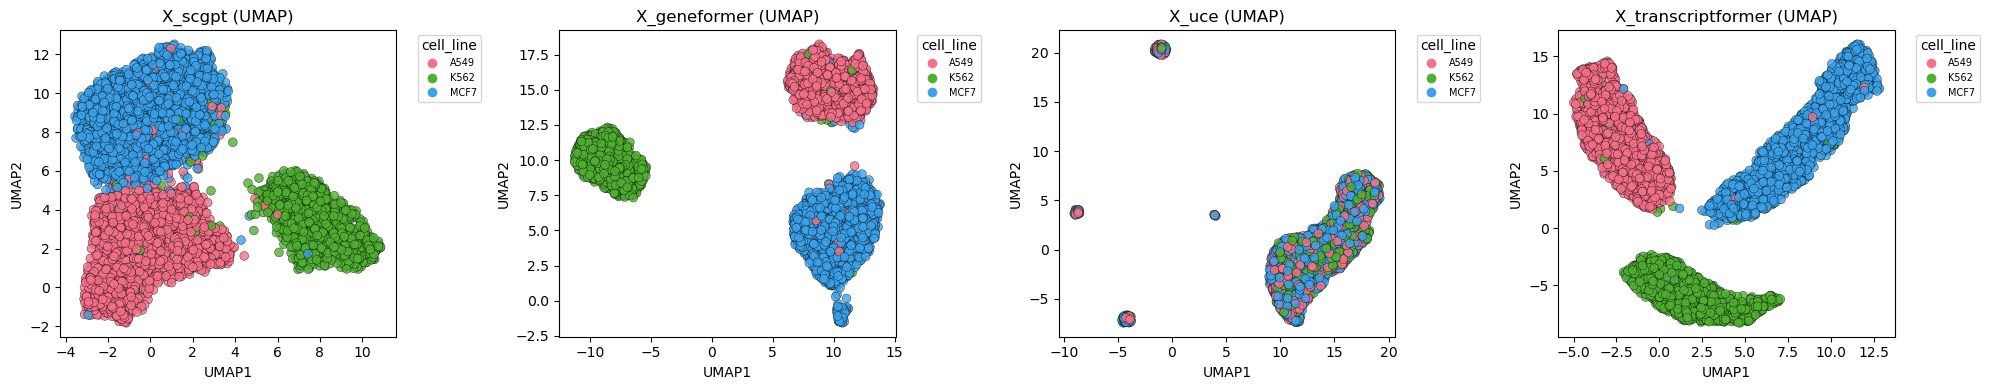

In [10]:
import embpy.pl as epl

# Park each model's embeddings in .obsm so the embpy plotting utilities
# can address them by key (and reuse them in the next cells).
adata.obsm["X_scgpt"] = embs_scgpt
adata.obsm["X_geneformer"] = embs_gf
adata.obsm["X_uce"] = embs_uce
adata.obsm["X_transcriptformer"] = embs_tf

# `all_embeddings` computes a UMAP per embedding key (via embpy.tl.compute_umap,
# which wraps scanpy's pp.neighbors + tl.umap) and draws a grid of 2-D scatters
# colored by `color`. The UMAP coordinates are cached in .obsm[f"X_umap_{key}"],
# so re-running this cell is cheap.
fig = epl.all_embeddings(
    adata,
    obsm_keys=["X_scgpt", "X_geneformer", "X_uce", "X_transcriptformer"],
    method="umap",
    color="cell_line",
    ncols=4,
    figsize_per_panel=(5, 4),
)
fig.show()

## 5. Store embeddings in AnnData

It's convenient to store embeddings in `adata.obsm` for downstream analyses.

In [11]:
# The foundation-model embeddings were stored in `.obsm` in section 4
# (so `all_embeddings` could address them by key). The UMAP plot step also
# cached per-embedding coordinates in `X_umap_<key>` -- both are already
# part of the AnnData and ready for downstream scanpy/scvi workflows.
print("Stored embedding keys:", list(adata.obsm.keys()))
adata

Stored embedding keys: ['X_scgpt', 'X_geneformer', 'X_uce', 'X_transcriptformer', 'X_umap', 'X_umap_X_scgpt', 'X_umap_X_geneformer', 'X_umap_X_uce', 'X_umap_X_transcriptformer']


AnnData object with n_obs × n_vars = 5000 × 110983
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'total_counts', 'assay'
    var: 'ensembl_id', 'index', 'id_in_vocab', 'ensembl_id_collapsed'
    uns: 'neighbors', 'umap'
    obsm: 'X_scgpt', 'X_geneformer', 'X_uce', 'X_transcriptformer', 'X_umap', 'X_umap_X_scgpt', 'X_umap_X_geneformer', 'X_umap_X_uce', 'X_umap_X_transcriptformer'
    obsp: 'distances', 'connectivities'

## 6. Using the wrapper classes directly

Instead of the factory, you can instantiate wrappers directly for
more control over configuration.

In [12]:
from embpy.models.singlecell_models import ScGPTWrapper

wrapper = ScGPTWrapper(batch_size=16)
wrapper.load(device)
print(f"Loaded: {wrapper}")
print(f"Embedding dim: {wrapper.embedding_dim}")

INFO:helical.models.scgpt.model:Model finished initializing.
2026-05-04 12:01:09,482 - INFO:helical.models.scgpt.model:Model finished initializing.
INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-04 12:01:09,483 - INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
INFO:embpy.models.singlecell_models:Loaded scGPT on cuda
2026-05-04 12:01:09,485 - INFO:embpy.models.singlecell_models:Loaded scGPT on cuda


Loaded: ScGPTWrapper(model_name='ScGPTWrapper', device='cuda')
Embedding dim: 512


## 7. Larger models: Tahoe-x1 and Cell2Sentence-Scale

These models are substantially larger than the transformer-era
foundation models above. In particular, **Cell2Sentence-Scale 2B**
is a full Gemma-2 LLM (~5 GB of weights in bf16, plus large
activation buffers) and the 27B variant needs multi-GPU.

If your notebook has already loaded several of the smaller models,
their weights are still resident on the GPU -- so before loading
Cell2Sentence we explicitly free them and subsample `adata` to a
size that comfortably fits on a single 20-40 GB GPU.


In [13]:
# Tahoe-x1 (70M — smallest variant)
tahoe = get_singlecell_wrapper("tahoe_70m", batch_size=10)
tahoe.load(device)

embs_tahoe = tahoe.embed_cells(adata)
print(f"Tahoe-x1 70M embeddings: {embs_tahoe.shape}")

INFO:helical.models.tahoe.model:Loading Tahoe model (size: 70m) from Hugging Face...
2026-05-04 12:01:20,523 - INFO:helical.models.tahoe.model:Loading Tahoe model (size: 70m) from Hugging Face...
INFO:helical.models.tahoe.tahoe_x1.model.model:MosaicML recommends using config.init_device="meta" with Composer + FSDP for faster initialization.
2026-05-04 12:01:22,570 - INFO:helical.models.tahoe.tahoe_x1.model.model:MosaicML recommends using config.init_device="meta" with Composer + FSDP for faster initialization.
INFO:helical.models.tahoe.model:Model loaded with 12 transformer layers.
2026-05-04 12:01:28,088 - INFO:helical.models.tahoe.model:Model loaded with 12 transformer layers.
INFO:helical.models.tahoe.model:Tahoe model is in 'eval' mode, on device 'cuda' with embedding mode 'cell' and attention implementation 'torch'.
2026-05-04 12:01:28,090 - INFO:helical.models.tahoe.model:Tahoe model is in 'eval' mode, on device 'cuda' with embedding mode 'cell' and attention implementation 'torc

Embedding cells:   0%|          | 0/500 [00:00<?, ?it/s]

INFO:helical.models.tahoe.model:Finished extracting embeddings. Cell shape: (5000, 512)
2026-05-04 12:02:19,844 - INFO:helical.models.tahoe.model:Finished extracting embeddings. Cell shape: (5000, 512)


Tahoe-x1 70M embeddings: (5000, 512)


In [14]:
import gc
import os

# Reduce allocator fragmentation. For full effect this must be set
# BEFORE `import torch`; we set it here defensively so re-runs benefit.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Free every wrapper loaded earlier in this kernel. Each wrapper holds
# a `._model` reference to a large torch module whose parameters live
# on the GPU; dropping the wrapper is not enough -- we also clear the
# allocator's reserved blocks.
for _name in ("scgpt", "gf", "uce", "tf", "tahoe", "wrapper"):
    globals().pop(_name, None)
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.synchronize()
free_gb, total_gb = (x / 1024**3 for x in torch.cuda.mem_get_info())
print(f"Free GPU memory before loading C2S: {free_gb:.2f} / {total_gb:.2f} GiB")

# Subsample to keep activations within a single 20-40 GB GPU. Cell2Sentence
# tokenizes cells into gene-rank sentences of up to ~9k tokens each,
# so even a batch size of 1 is memory-heavy.
N_C2S = 200
adata_small = adata[:N_C2S].copy()

c2s = get_singlecell_wrapper("cell2sentence_2b", batch_size=1)
c2s.load(device)

embs_c2s = c2s.embed_cells(adata_small)
print(f"Cell2Sentence-Scale 2B embeddings: {embs_c2s.shape}  (on {N_C2S} cells)")

INFO:helical.models.c2s.model:Using SDPA for attention implementation - default for CPU
2026-05-04 12:02:20,473 - INFO:helical.models.c2s.model:Using SDPA for attention implementation - default for CPU


Free GPU memory before loading C2S: 72.63 / 79.25 GiB


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:helical.models.c2s.model:Successfully loaded model
2026-05-04 12:02:34,452 - INFO:helical.models.c2s.model:Successfully loaded model
INFO:embpy.models.singlecell_models:Loaded Cell2Sentence-Scale '2B' on cuda
2026-05-04 12:02:34,454 - INFO:embpy.models.singlecell_models:Loaded Cell2Sentence-Scale '2B' on cuda
INFO:helical.models.c2s.model:Processing data
2026-05-04 12:02:34,455 - INFO:helical.models.c2s.model:Processing data
Processing cells: 100%|██████████| 200/200 [00:00<00:00, 8149.66it/s]
INFO:helical.models.c2s.model:Successfully processed data
2026-05-04 12:02:37,561 - INFO:helical.models.c2s.model:Successfully processed data
INFO:helical.models.c2s.model:Extracting embeddings from dataset
2026-05-04 12:02:37,563 - INFO:helical.models.c2s.model:Extracting embeddings from dataset
Processing embeddings: 100%|██████████| 200/200 [00:56<00:00,  3.57it/s]
INFO:helical.models.c2s.model:Successfully extracted embeddings
2026-05-04 12:03:33,707 - INFO:helical.models.c2s.model:Succe

Cell2Sentence-Scale 2B embeddings: (200, 2304)  (on 200 cells)


## 8. Cross-model agreement on the same cells

A single cell-vs-cell cosine matrix for one model is hard to interpret in
isolation. The sharper question is: **do different foundation models
agree on which cells are similar to which?** Because each model lives
in its own embedding space (scGPT is 512-D, Geneformer is 512-D, UCE is
1280-D, TranscriptFormer is 128-D), we cannot cosine cells across
models directly. Instead we compare their *relational* structure:

1. Compute the cell-vs-cell cosine matrix in each model's space.
2. Compare those matrices pairwise (Pearson correlation of the
   upper triangles; equivalent to representational similarity analysis).

High agreement means the models place the same cells near each other
even though their raw embedding coordinates are incomparable.

`embpy.pl.cross_model_similarity` does exactly this, with three
interchangeable agreement metrics:

- `method="cosine_correlation"` -- Pearson r between the cosine matrices (RSA-style).
- `method="knn"` -- mean Jaccard overlap of k-nearest-neighbour sets per cell.
- `method="ari"` -- Adjusted Rand Index between Leiden clusterings.

INFO:root:KNN overlap (k=20) between 'X_scgpt' and 'X_geneformer': mean Jaccard = 0.0422
2026-05-04 12:03:37,587 - INFO:root:KNN overlap (k=20) between 'X_scgpt' and 'X_geneformer': mean Jaccard = 0.0422
INFO:root:KNN overlap (k=20) between 'X_scgpt' and 'X_uce': mean Jaccard = 0.0022
2026-05-04 12:03:38,266 - INFO:root:KNN overlap (k=20) between 'X_scgpt' and 'X_uce': mean Jaccard = 0.0022
INFO:root:KNN overlap (k=20) between 'X_scgpt' and 'X_transcriptformer': mean Jaccard = 0.0386
2026-05-04 12:03:39,024 - INFO:root:KNN overlap (k=20) between 'X_scgpt' and 'X_transcriptformer': mean Jaccard = 0.0386
INFO:root:KNN overlap (k=20) between 'X_geneformer' and 'X_uce': mean Jaccard = 0.0022
2026-05-04 12:03:39,699 - INFO:root:KNN overlap (k=20) between 'X_geneformer' and 'X_uce': mean Jaccard = 0.0022
INFO:root:KNN overlap (k=20) between 'X_geneformer' and 'X_transcriptformer': mean Jaccard = 0.0951
2026-05-04 12:03:40,454 - INFO:root:KNN overlap (k=20) between 'X_geneformer' and 'X_trans

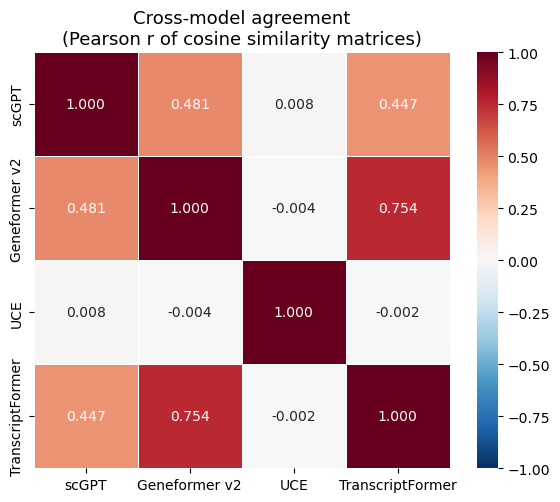

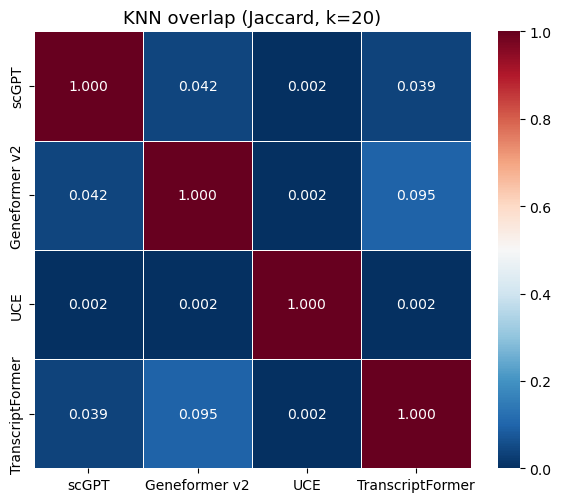

In [15]:
# RSA-style agreement: how correlated are the cell-vs-cell cosine matrices
# of the four models? Values near +1 mean two models rank cell-cell
# similarities nearly identically; near 0 means they disagree.
fig_rsa = epl.cross_model_similarity(
    adata,
    obsm_keys=["X_scgpt", "X_geneformer", "X_uce", "X_transcriptformer"],
    labels=["scGPT", "Geneformer v2", "UCE", "TranscriptFormer"],
    method="cosine_correlation",
    figsize=(6, 5),
)
fig_rsa.show()

# Local-neighbourhood agreement: for each cell, how much do the
# k-nearest-neighbour sets overlap between models (mean Jaccard, k=20)?
# This is a stricter, cell-resolution view of the same question.
fig_knn = epl.cross_model_similarity(
    adata,
    obsm_keys=["X_scgpt", "X_geneformer", "X_uce", "X_transcriptformer"],
    labels=["scGPT", "Geneformer v2", "UCE", "TranscriptFormer"],
    method="knn",
    k=20,
    figsize=(6, 5),
)
fig_knn.show()

## 9. Preprocessing Pipelines

`embpy` provides two preprocessing pipelines via `preprocess_counts()`:

- **`"standard"`** -- filter, normalize, log1p, HVG selection.
  Stores raw counts in `.layers["counts"]` and processed data in
  `.layers["log_normalized"]`, while `.X` is restored to raw.
- **`"raw"`** -- QC filtering only, raw counts in `.X`.

In [16]:
from embpy.pp.singlecell import preprocess_counts

adata_processed = preprocess_counts(
    adata,
    pipeline="standard",
    n_top_genes=2000,
)

print("Layers:", list(adata_processed.layers.keys()))
print(f".X shape (raw counts): {adata_processed.X.shape}")
print(f".layers['counts'] shape: {adata_processed.layers['counts'].shape}")
print(f".layers['log_normalized'] shape: {adata_processed.layers['log_normalized'].shape}")
if "highly_variable" in adata_processed.var.columns:
    n_hvg = adata_processed.var["highly_variable"].sum()
    print(f"HVGs marked: {n_hvg}")

INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
2026-05-04 12:03:42,939 - INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 12:03:45,191 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
2026-05-04 12:03:45,201 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X


Layers: ['counts', 'log_normalized']
.X shape (raw counts): (4998, 23166)
.layers['counts'] shape: (4998, 23166)
.layers['log_normalized'] shape: (4998, 23166)
HVGs marked: 2000


## 10. PCA and scVI Embeddings

Beyond foundation models, `embpy` supports classical PCA and scVI
(variational autoencoder) as cell embedding methods. These are available
through the same `embed_cells()` interface.

In [17]:
from embpy.embedder import BioEmbedder

embedder = BioEmbedder(device="auto")

# PCA embedding (50 components on log-normalized HVGs)
result_pca = embedder.embed_cells(
    adata,
    models=["pca"],
    preprocessing="standard",
    n_pca_components=50,
    n_top_genes=2000,
)
print(f"PCA embedding: {result_pca.obsm['X_pca'].shape}")
print(f"Layers: {list(result_pca.layers.keys())}")

INFO:root:CUDA device found, using GPU.
2026-05-04 12:03:45,226 - INFO:root:CUDA device found, using GPU.
INFO:root:GeneResolver initialized for human (Release 109).
2026-05-04 12:03:45,226 - INFO:root:GeneResolver initialized for human (Release 109).
INFO:root:Checking if Ensembl data needs downloading/indexing...
2026-05-04 12:03:54,883 - INFO:root:Checking if Ensembl data needs downloading/indexing...
INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
2026-05-04 12:03:55,514 - INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.ncrna.fa.gz.pickle
2026-05-04 12:03:55,745 - INFO:pyensembl.sequence_data:Loaded sequence dictionary f

PCA embedding: (4998, 50)
Layers: ['counts', 'log_normalized']


In [18]:
# scVI latent space (requires scvi-tools: `pip install scvi-tools` or
# `pixi add --feature helical scvi-tools`).
#
# `embed_cells` is resilient to missing model backends: if a model fails
# to load (e.g. `scvi-tools` not installed) it logs an error and returns
# the AnnData without that embedding in `.obsm`. So we check by key
# rather than catching ImportError.
result_scvi = embedder.embed_cells(
    adata,
    models=["scvi"],
    preprocessing="standard",
    n_latent=30,
    max_epochs=50,
    n_top_genes=2000,
)

if "X_scvi" in result_scvi.obsm:
    print(f"scVI embedding: {result_scvi.obsm['X_scvi'].shape}")
else:
    print(
        "scVI embedding not produced -- scvi-tools is likely not installed "
        "in this pixi env. See the log line above for the exact error."
    )

INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
2026-05-04 12:03:59,095 - INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 12:03:59,266 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
2026-05-04 12:03:59,271 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
INFO:root:Embedding cells with 'scvi' ...
2026-05-04 12:03:59,272 - INFO:root:Embedding cells with 'scvi' ...
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
2026-05-04 12:04:16,599 - INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
2026-05-04 12:04:41,092 - INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:embpy.models.singlecell_models:SCVI: trained 50 epochs, latent shape (4998, 30)
2026-05-04 12:04:41,229 - INFO:embpy.models.singlecell_models:SCVI: trained 50 epochs, latent shape (4998, 30)
INFO:root:  -> stored in .obsm['X_scvi'], shape (4998, 30)
2026-05-04 12:04:41,230 - INFO:root:  -> stored in .obsm['X_scvi'], shape (4998, 30)
INFO:root:embed_cells complete: 1 models, 4998 cells
2026-05-04 12:04:41,231 - INFO:root:embed_cells complete: 1 models, 4998 cells


scVI embedding: (4998, 30)


## 11. Multi-Model Embedding in One Call

Pass multiple model keys to `embed_cells()` to compute all embeddings
at once. Each is stored under its own `.obsm` key.

In [19]:
result = embedder.embed_cells(
    adata,
    models=["pca", "scgpt"],
    preprocessing="standard",
    n_pca_components=50,
    n_top_genes=2000,
    batch_size=10,
)

print("Embedding keys in .obsm:")
for key in sorted(result.obsm.keys()):
    print(f"  {key}: shape {result.obsm[key].shape}")

print(f"\n.X (raw counts): {result.X.shape}")
print(f"Layers: {list(result.layers.keys())}")
print(f"Metadata: {list(result.uns.get('embpy_cell_embeddings', {}).keys())}")

INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
2026-05-04 12:04:41,595 - INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 12:04:41,767 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
2026-05-04 12:04:41,772 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
INFO:root:Embedding cells with 'pca' ...
2026-05-04 12:04:41,773 - INFO:root:Embedding cells with 'pca' ...
INFO:embpy.models.singlecell_models:PCA (backend=cpu): 2000 -> 50 components (14.1% variance explained)
2026-05-04 12:04:42,478 - INFO:embpy.models.singlecell_models:PCA (backend=cpu): 2000 -> 50 components (14.1% variance e

Embedding keys in .obsm:
  X_geneformer: shape (4998, 512)
  X_pca: shape (4998, 50)
  X_scgpt: shape (4998, 512)
  X_transcriptformer: shape (4998, 2048)
  X_uce: shape (4998, 1280)
  X_umap: shape (4998, 2)
  X_umap_X_geneformer: shape (4998, 2)
  X_umap_X_scgpt: shape (4998, 2)
  X_umap_X_transcriptformer: shape (4998, 2)
  X_umap_X_uce: shape (4998, 2)

.X (raw counts): (4998, 23166)
Layers: ['counts', 'log_normalized']
Metadata: ['pca', 'scgpt__vocab', 'scgpt']


## 12. Production workloads: auto-vocab conversion + wrapper caching

Real-world datasets rarely come in the exact gene-identifier convention every foundation model expects. A perturbation screen may ship Ensembl IDs in `.var_names`, scGPT wants gene symbols, Geneformer wants Ensembl IDs, and STATE/STACK want symbols again. Manually rekeying `adata.var_names` for each model is tedious and error-prone.

On top of that, evaluation pipelines typically call `embed_cells` many times (chunked inference over a large AnnData, sweeping a grid of perturbations, cross-validation folds). Instantiating a large torch model on the GPU for every call is wasteful.

`BioEmbedder` handles both of these automatically:

1. **Vocabulary detection + conversion.** Each registered model carries a `vocab_type` (`"symbol"` / `"ensembl_id"` / `"either"` / `"any"`). `embed_cells` sniffs the input `var_names`, and when they don't match, routes through `GeneResolver` (pyensembl-backed, with MyGene.info / Ensembl REST fallbacks) to remap them. The converted AnnData is a copy; the original is left untouched.

2. **Wrapper caching.** Foundation-model wrappers (scGPT, Geneformer, UCE, Tahoe, ...) are cached on a `BioEmbedder` instance by `(model_key, device)`. Repeated calls reuse the loaded torch model instead of re-instantiating it on the GPU.

The test below uses the D1_Rest Perturb-seq subsample from the `genetic_chemical_integration` project (Ensembl IDs in `.var_names`) to exercise both mechanisms on a realistic workload.

In [20]:
import time
import anndata as ad
import numpy as np
from embpy.embedder import BioEmbedder

# Perturb-seq HVG subsample used by the `genetic_chemical_integration` project.
# var_names are Ensembl IDs; gene symbols are parked in .var["gene_name"].
LARGE_PATH = (
    "/lustre/groups/ml01/workspace/hediyehzadeh.s/projects/"
    "perturbation_projects/genetic_chemical_integration/EBM_SA_model/"
    "data/preprocessed/D1_Rest.assigned_guide_5k_hvg_equalSubSample200.h5ad"
)

adata_big = ad.read_h5ad(LARGE_PATH)
# Subsample cells to keep the demo fast; drop to 1000 cells is plenty to
# show the cache speedup and vocabulary auto-conversion end-to-end.
if adata_big.n_obs > 1000:
    rng = np.random.default_rng(0)
    keep = rng.choice(adata_big.n_obs, size=1000, replace=False)
    adata_big = adata_big[keep].copy()

print(f"Loaded {adata_big.n_obs:,} cells x {adata_big.n_vars:,} genes")
print(f"var_names[:3] = {list(adata_big.var_names[:3])}  (Ensembl IDs)")
print(f"var.gene_name[:3] = {list(adata_big.var['gene_name'].astype(str)[:3])}")
print()

# Single BioEmbedder instance reused across calls -> cache + vocab
# conversion kick in on the second call.
embedder_big = BioEmbedder(organism="human")

timings = []
for i in range(3):
    t0 = time.perf_counter()
    result = embedder_big.embed_cells(
        adata_big,
        models=["scgpt"],  # "symbol"-vocab model on Ensembl-ID data
        preprocessing="standard",
        n_top_genes=2000,
        batch_size=32,
        # vocab_conversion="auto" is the default; pass "off" to opt out.
    )
    timings.append(time.perf_counter() - t0)
    kind = "cold" if i == 0 else f"warm {i}"
    print(f"call {i + 1} ({kind:>6}): {timings[-1]:6.2f} s  -> obsm['X_scgpt'] shape {result.obsm['X_scgpt'].shape}")

speedup = timings[0] / timings[-1] if timings[-1] else float("nan")
print(f"\nspeedup (cold / warm{len(timings) - 1}) = {speedup:.1f}x")
print(f"cached wrappers: {list(embedder_big._singlecell_cache.keys())}")

# Per-call auto-conversion report is stashed in uns for auditing.
vocab_report = result.uns.get("embpy_cell_embeddings", {}).get("scgpt__vocab")
print(f"vocab report: {vocab_report}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/lustre/groups/ml01/workspace/hediyehzadeh.s/projects/perturbation_projects/genetic_chemical_integration/EBM_SA_model/data/preprocessed/D1_Rest.assigned_guide_5k_hvg_equalSubSample200.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

### Opting out and freeing GPU memory

If for any reason you want the old behavior -- pass `adata.var_names` straight through to the model without a conversion attempt -- use `vocab_conversion="off"`. And when you are done with a model (or need to load a bigger one on the same GPU), call `clear_model_cache()` to drop the cached wrapper and reclaim the GPU memory.

In [ ]:
# Opt out of the auto-conversion path. scGPT's internal gene-filter will then
# see raw Ensembl IDs, find zero overlap with its vocabulary, and produce
# meaningless embeddings -- this is exactly the silent failure the auto path
# protects you from.
result_raw = embedder_big.embed_cells(
    adata_big,
    models=["scgpt"],
    preprocessing="standard",
    n_top_genes=2000,
    batch_size=32,
    vocab_conversion="off",
)
print(
    "With vocab_conversion='off', n_genes seen by scGPT was effectively 0 "
    "(see the 'Filtering out ... to a total of ...' log line above)."
)

# Drop the cached wrappers on this embedder and release GPU memory.
embedder_big.clear_model_cache()
print(f"after clear_model_cache: cached wrappers = {list(embedder_big._singlecell_cache.keys())}")

INFO:embpy.pp.singlecell.preprocessing:After QC: 997 cells x 3279 genes
2026-05-04 09:41:47,451 - INFO:embpy.pp.singlecell.preprocessing:After QC: 997 cells x 3279 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 09:41:47,524 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 997 cells x 3279 genes, log_normalized in .layers, raw counts in .X
2026-05-04 09:41:47,525 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 997 cells x 3279 genes, log_normalized in .layers, raw counts in .X
INFO:root:Embedding cells with 'scgpt' ...
2026-05-04 09:41:47,526 - INFO:root:Embedding cells with 'scgpt' ...
INFO:helical.models.scgpt.model:Processing data for scGPT.
2026-05-04 09:41:47,526 - INFO:helical.models.scgpt.model:Processing data for scGPT.
INFO:helical.models.scgpt.model:Filtering out 3279 genes to a total of 0 genes with 

With vocab_conversion='off', n_genes seen by scGPT was effectively 0 (see the 'Filtering out ... to a total of ...' log line above).
after clear_model_cache: cached wrappers = []


## 13. Encoder-decoder workflows: decode latents back to gene expression

Most of the models above are encoder-only -- they produce a fixed-dimensional embedding per cell. A separate family of models exposes both an **encoder** (gene expression -> latent) and a **decoder** (latent -> gene expression):

| Model | Capability | Typical use |
|-------|------------|-------------|
| `pca` | encode + decode (linear) | fast baseline, interpretable, analytic inverse |
| `scvi` / `scanvi` / `totalvi` | encode + decode (probabilistic) | batch correction, denoising, counterfactual expression |
| `state` (Arc Institute) | encode + decode | large-scale foundation model with a learned decoder |
| `stack` (Arc Institute) | **in-context generation** | predict expression for unseen cells conditioned on a context set |

`embpy` exposes three public entry points on `BioEmbedder`:

- `embed_cells(...)`  -> fit + encode (latents stored in `adata.obsm[...]`)
- `decode_cells(...)` -> route latents back through the cached decoder (e.g. for perturbation flow-matching decoders)
- `generate_cells(...)` -> Stack-style in-context expression synthesis

Discoverability:

```python
from embpy.models.singlecell_models import singlecell_info
card = singlecell_info("scvi")
print(card.supports_decode, card.supports_generation)
```


### 13a. PCA: analytic encode -> decode round-trip

PCA is the simplest encoder-decoder in the registry. Fitting it caches both the fitted ``sklearn`` model and the HVG mask on the wrapper, so a subsequent ``decode_cells`` call reconstructs the full gene panel. Non-HVG genes (which did not participate in the PCA fit) are deterministically zero-padded in the reconstruction, and the user is responsible for knowing which columns were reconstructed vs. imputed.


In [ ]:
import numpy as np

# Reuse the `embedder` and `adata` objects created in the previous sections.
# We embed with PCA so that BioEmbedder caches the fitted wrapper on this
# instance -- that cached wrapper is what decode_cells() will route through.
adata_pca = embedder.embed_cells(
    adata,
    models=["pca"],
    preprocessing="standard",
    n_top_genes=2000,
    n_pca_components=30,
    copy=True,
)
print("Latent space shape:", adata_pca.obsm["X_pca"].shape)

# Decode latents -> gene-expression space. By default decode_cells reads
# from adata.obsm[<auto-detected key>]; we also persist the reconstruction
# in adata.layers for downstream comparison.
X_recon = embedder.decode_cells(
    adata=adata_pca,
    model="pca",
    write_layer="X_pca_decoded",
)
print("Reconstruction shape:", X_recon.shape)

# Quality check: how well does PCA(k=30) reconstruct each cell on the
# highly-variable genes it was actually fit on?
X_orig = np.asarray(adata_pca.layers["log_normalized"], dtype=np.float32)
hvg_mask = adata_pca.var["highly_variable"].to_numpy(dtype=bool)

r_cells = np.asarray([np.corrcoef(X_orig[i, hvg_mask], X_recon[i, hvg_mask])[0, 1] for i in range(adata_pca.n_obs)])
print(
    f"Per-cell Pearson r on HVGs: median={np.median(r_cells):.3f}, min={np.min(r_cells):.3f}, max={np.max(r_cells):.3f}"
)
print("Non-HVG columns are zero-padded by design:", np.allclose(X_recon[:, ~hvg_mask], 0.0))

### 13b. scVI: probabilistic decoder (`px_rate`)

scVI learns a variational encoder and a generative decoder that parameterises a negative-binomial likelihood. `embpy` caches the trained `scvi` model on the `BioEmbedder` instance during `embed_cells`, and `decode_cells` then routes latent codes back through `module.generative(...)` to recover the expected expression rate ``px_rate``. This gives you the same "latent -> expression" hook that flow-matching perturbation models (e.g. CellFlow) depend on, without leaving `embpy`.

Requires `scvi-tools` to be installed in the current environment. In the bundled Pixi environments it is available in `helical-gpu`. If it is not installed, this cell skips gracefully.


In [ ]:
try:
    import scvi  # noqa: F401

    have_scvi = True
except ImportError:
    have_scvi = False
    print(
        "scvi-tools not installed - skipping scVI decode demo. "
        "Use the `helical-gpu` Pixi env or `pip install scvi-tools`."
    )

if have_scvi:
    adata_scvi = embedder.embed_cells(
        adata,
        models=["scvi"],
        preprocessing="standard",
        n_top_genes=2000,
        n_latent=20,
        max_epochs=30,
        copy=True,
    )
    print("scVI latent shape:", adata_scvi.obsm["X_scvi"].shape)

    # Route the scVI latent codes back through the decoder.
    X_scvi_recon = embedder.decode_cells(
        adata=adata_scvi,
        model="scvi",
        write_layer="X_scvi_decoded",
    )
    print("scVI decoded expression shape:", X_scvi_recon.shape)
    print("Expected (non-negative) rates? min =", float(X_scvi_recon.min()), " max =", float(X_scvi_recon.max()))

    # Counterfactual use: interpolate between two cells in latent space,
    # decode, and inspect the implied expression trajectory.
    z = adata_scvi.obsm["X_scvi"]
    z_mix = 0.5 * z[:1] + 0.5 * z[1:2]  # midpoint between the first two cells
    X_midpoint = embedder.decode_cells(
        latent=z_mix.astype(np.float32),
        model="scvi",
    )
    print("Counterfactual midpoint expression shape:", X_midpoint.shape)

### 13c. STATE and Stack (Arc Institute)

> **Switch Pixi environments first!**
>
> STATE and Stack require a different scientific stack than the helical models above (`pytorch >= 2.7`, `scipy >= 1.15`, `transformers >= 4.52`). They live in the dedicated `arc-gpu` Pixi environment -- trying to import `state` / `stack` from the `helical-gpu` kernel will fail.
>
> **What to do:**
> 1. Stop the current JupyterLab job (`scancel <JOBID>` for the helical launcher).
> 2. From the repo root, launch the arc launcher:
>
>    ```bash
>    sbatch submission_scripts/jupyter_pixi_arc.sbatch
>    ```
>
> 3. Open the URL in the new log (`submission_scripts/logs/jupyter_pixi_arc_<JOBID>.out`) and reconnect this notebook to it via "Select Another Kernel..." -> "Existing Jupyter Server...".
>
> If you haven't installed the environment yet, do so once on the login node:
> ```bash
> CONDA_OVERRIDE_CUDA=12.0 pixi install -e arc-gpu
> ```

[STATE](https://github.com/ArcInstitute/state) is a Transformer-based single-cell foundation model with a paired decoder, and [Stack](https://github.com/ArcInstitute/stack) is its in-context generation counterpart -- given a *context set* of cells and a *test set* of cells, Stack predicts gene expression for the test cells without any additional training.

The cells below show the **API contract**, not a full end-to-end run -- downloading the Arc checkpoints (multi-GB) is out of scope for this tutorial. Fill in the paths to your local copies to execute.


In [ ]:
from embpy.models.singlecell_models import StateEmbeddingWrapper, singlecell_info

# Environment guard: arc-state only lives in the `arc-gpu` Pixi env.
try:
    import state  # noqa: F401

    have_state = True
except ImportError:
    have_state = False
    print("arc-state is not installed in the current kernel.")
    print("Relaunch JupyterLab with:")
    print("    sbatch submission_scripts/jupyter_pixi_arc.sbatch")
    print("and reconnect this notebook to that server.\n")
    print("Model card (env-independent):", singlecell_info("state"))

# === Fill in the path(s) to your downloaded STATE checkpoint ===
STATE_CHECKPOINT = None  # e.g. "/lustre/.../state_model.ckpt"
STATE_MODEL_FOLDER = None  # alternative: a folder with config+weights

run_state_demo = have_state and (STATE_CHECKPOINT is not None or STATE_MODEL_FOLDER is not None)

if run_state_demo:
    state_wrapper = StateEmbeddingWrapper(
        checkpoint=STATE_CHECKPOINT,
        model_folder=STATE_MODEL_FOLDER,
    )
    state_wrapper.load("cuda" if torch.cuda.is_available() else "cpu")

    # Encode: cell -> latent
    Z_state = state_wrapper.embed_cells(adata)
    print("STATE latent shape:", Z_state.shape)

    # Decode: latent -> gene-wise log-probabilities.
    # STATE's decoder is *gene-parametric*: you must pass the list of gene
    # symbols you want to reconstruct.
    X_state_recon = state_wrapper.decode_cells(
        Z_state,
        gene_names=list(adata.var_names),
    )
    print("STATE decoded expression shape:", X_state_recon.shape)
elif have_state:
    print("Skipping STATE demo - set STATE_CHECKPOINT or STATE_MODEL_FOLDER to a valid path to run it.")

In [ ]:
from embpy.models.singlecell_models import StackWrapper

# Environment guard: arc-stack only lives in the `arc-gpu` Pixi env.
try:
    import stack as _stack  # noqa: F401

    have_stack = True
except ImportError:
    have_stack = False
    print("arc-stack is not installed in the current kernel.")
    print("Relaunch JupyterLab with:")
    print("    sbatch submission_scripts/jupyter_pixi_arc.sbatch")
    print("and reconnect this notebook to that server.\n")
    print("Model card (env-independent):", singlecell_info("stack"))

# === Fill in the paths to your Stack checkpoint + gene list ===
STACK_CHECKPOINT = None  # e.g. "/lustre/.../stack.ckpt"
STACK_GENELIST = None  # e.g. "/lustre/.../stack_genelist.pkl"

run_stack_demo = have_stack and (STACK_CHECKPOINT is not None and STACK_GENELIST is not None)

if run_stack_demo:
    stack_wrapper = StackWrapper(
        checkpoint=STACK_CHECKPOINT,
        genelist=STACK_GENELIST,
        gene_name_col="gene_symbol",  # adjust to match your adata.var
    )
    stack_wrapper.load("cuda" if torch.cuda.is_available() else "cpu")

    # In-context generation: predict expression for the "test" cells
    # conditioned on the "base" (context) cells. We fake a split here by
    # carving the single-cell panel in two.
    base_adata = adata[: adata.n_obs // 2].copy()
    test_adata = adata[adata.n_obs // 2 :].copy()

    # The public entry-point on BioEmbedder routes through the wrapper.
    # We must pass the constructed wrapper explicitly because Stack needs
    # the checkpoint+genelist paths which BioEmbedder cannot infer.
    X_generated = embedder.generate_cells(
        base_adata,
        test_adata,
        model="stack",
        wrapper=stack_wrapper,
        # Optional: condition on a per-cell split column (e.g. donor, lane).
        # split_column="donor",
        # split_values=["donor_A"],
    )
    print("Stack-generated expression shape:", X_generated.shape)
elif have_stack:
    print("Skipping Stack demo - set STACK_CHECKPOINT and STACK_GENELIST to valid paths to run it.")

## Summary

This tutorial showed how to:

- **List** all 20+ single-cell foundation model variants via `list_singlecell_models()`
- **Load** any model with the 3-step pattern: instantiate -> load -> embed
- **Compare** embedding spaces across models using UMAP visualisation (`embpy.pl`) and cross-model agreement (`cross_model_similarity`)
- **Store** embeddings in `adata.obsm` for seamless integration with scanpy/scvi
- **Scale** to real datasets with built-in `BioEmbedder` facilities:
    - automatic gene-vocabulary detection + conversion (`vocab_conversion="auto"`)
    - wrapper caching across repeated `embed_cells` calls
    - explicit GPU cleanup via `BioEmbedder.clear_model_cache()`
- **Decode** latent codes back to gene expression with `BioEmbedder.decode_cells()` for PCA, scVI, and STATE -- the same hook that flow-matching perturbation models (e.g. CellFlow) consume
- **Generate** expression for unseen cells from a context set with `BioEmbedder.generate_cells()` routed through Stack

Key functions:

```python
from embpy.embedder import BioEmbedder
from embpy.models.singlecell_models import (
    list_singlecell_models,   # discover available models
    singlecell_info,          # model metadata (incl. supports_decode / supports_generation)
    get_singlecell_wrapper,   # factory function
)

embedder = BioEmbedder(device="cuda")
embedder.embed_cells(adata, models=["pca", "scvi"])  # encode
embedder.decode_cells(adata=adata, model="scvi")     # latent -> expression
embedder.generate_cells(base_adata, test_adata,      # in-context synthesis
                        model="stack", wrapper=my_stack)
```

For the full list of models and variants, see the
[API reference](../api.md) or run `list_singlecell_models()`.